In [2]:
# features and label files
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv('X.csv',index_col=[0,1])
df2 = pd.read_csv('y.csv',index_col=[0,1])
m,n = df1.shape
#print(m,n)


columns = list(map(int,df1.columns.values))

coldict = {}
for i in range(n):
    coldict[columns[i]] = i

print(df2['beta_av'].idxmax(),df2['beta_av'].idxmin())
#print(df2)


maxdiff = max(df1.max(axis=1)-df1.min(axis=1)) 

for col in df1.columns:
    if col != '0':
        df1[col] = df1[col]-df1['0']
df1['0'] = df1['0'] - df1['0']

df1['beta_av'] = df2['beta_av']

print(df2['beta_av'].std())


def feature_corr():
    corrmat = df1.corr()
    #print(corrmat.loc['beta_av'])


    plt.figure(figsize = (15,15))
    sns.heatmap(corrmat,cmap='coolwarm')
    plt.savefig('heatmap.pdf', bbox_inches='tight')
    plt.show()
    plt.close() # Closes figure to free memory


#plt.figure(figsize = (15,15))
#plt.scatter(df1['0'],df1['602'])
#plt.show()


    


(3, 1) (20, 0)
11.642288392268995


In [3]:

# graph file
filename = "./td_c1_193_SCAFIR6_PT_list.log"
output_file_name = 'connection.txt'

text = "CONNECTION"

graphdict = {}


groupfile = './group.csv'
group = pd.read_csv(groupfile,index_col=0)

try:
    with open(filename, 'r') as infile, open(output_file_name, 'w') as outfile:
        for line in infile:
            if text in line and "?" not in line:
                
                outfile.write(line)
                fields = line.split()
                n1,n2 = group.loc[int(fields[2])]['group'],group.loc[int(fields[4])]['group']
                if n1 in coldict and n2 in coldict and n1!= n2:
                    graphdict[n1] = graphdict[n1]+[n2] if n1 in graphdict else [n2]
                    #graphdict[n2] = graphdict[n2] + [n1] if n2 in graphdict else [n1]
                    
                #print(n1,n2)
                #if c==count: break
    infile.close()
    outfile.close()
except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")


for i in graphdict:
    graphdict[i] = list(set(graphdict[i]))

#print(graphdict)


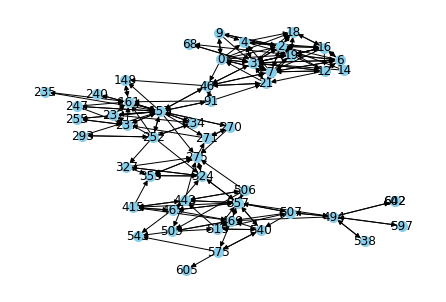

In [127]:
import networkx as nx



graph = nx.DiGraph(graphdict)

pos = nx.kamada_kawai_layout(graph)



import matplotlib.pyplot as plt
nx.draw(graph, pos=pos, with_labels=True, node_color='skyblue', node_size=100, edge_color='k', font_size=12)
plt.show()



In [128]:
#!pip install pyvis networkx
from pyvis.network import Network


G = nx.DiGraph()
for source, targets in graphdict.items():
    for target in targets:
        if source != target:
            G.add_edge(str(source), str(target))

net = Network(notebook=True, height="800px", width="100%", directed=True)
net.from_nx(G)

# 4. Show the network
net.show("network.html")



network.html


In [124]:
# maxflow mincut experiment

def capacity(v,n1,n2):
    x = (v.loc[n2]-v.loc[n1])/(maxdiff+0.0) # -1 to 1, higher energy gain -> lower capacity
    return 1-x/2

maxflow = [0]*m
mincut = [0]*m
mincuts = [0]*m
lastedge = [0]*m

for i in range(m):
    v = df1.iloc[i]
    for n1,n2 in graph.edges():
        #print(n1,n2,type(n1))
        graph.edges[n1,n2]['capacity']  =  capacity(v,str(n1),str(n2)) 
            #graph[u][v]['weight']  = energydiff2(v,n1,n2) 

#        print(f'{n1}, {n2}, {graph[n1][n2]['weight']}')
    #lastedge[i] = capacity(v,'494','602')
    maxflow[i] = nx.maximum_flow_value(graph, 0, 494)
    mincut[i],mincuts[i] = nx.minimum_cut(graph,0,494)
    #print(nx.minimum_cut(graph,0,602))

df2['maxflow'] = maxflow
df2['mincut'] = mincut
df2['lastedge'] = lastedge


#corr = df2['beta_av'].corr(df2[['maxflow','mincut']])
#print(corr)

#plt.figure(figsize=(10,10))
#plt.scatter(df2['beta_av'],df2['maxflow'])
#plt.show()

#plt.figure(figsize=(10,10))
#plt.scatter(df2['beta_av'],df2['mincut'])
#plt.show()

#plt.figure(figsize=(10,10))
#plt.scatter(df2['mincut'],df2['lastedge'])
#plt.show()



In [10]:
def compute_hitting_time(adj_matrix, start_node, target_node):
    """
    Computes hitting time from start_node to target_node.
    adj_matrix: Square 2D array where adj_matrix[i][j] = 1 if edge i->j exists.
    """
    n = len(adj_matrix)
    if start_node == target_node:
        return 0.0

    # 1. Convert adjacency matrix to transition matrix P
    # Row-normalize: each row sums to 1
    P = np.array(adj_matrix, dtype=float)
    row_sums = P.sum(axis=1)
    
    # Handle sink nodes (nodes with no outgoing edges) to avoid division by zero
    for i in range(n):
        if row_sums[i] > 0:
            P[i] /= row_sums[i]
        else:
            # If it's a sink and not the target, hitting time is infinite
            if i != target_node:
                P[i, i] = 1.0 

    # 2. Setup linear system: (I - P_reduced) * x = 1
    # We remove the row and column corresponding to the target node
    indices = [i for i in range(n) if i != target_node]
    P_reduced = P[np.ix_(indices, indices)]
    
    I = np.eye(len(indices))
    ones = np.ones(len(indices))
    
    try:
        # Solve for x in (I - P_reduced)x = ones
        hitting_times_sub = np.matmul(np.linalg.pinv(I - P_reduced),ones)
        
        # Map the result back to the original start_node index
        # Find the new index of our start_node in the reduced matrix
        mapped_start_idx = indices.index(start_node)
        #print(hitting_times_sub.shape," size")
        
        #print(hitting_times_sub)
        #print(hitting_times_sub.shape)
        
        #print(hitting_times_sub[mapped_start_idx])
        return hitting_times_sub[mapped_start_idx]
    
    except np.linalg.LinAlgError:
        return float('inf') # Target is unreachable


Experiement with -1: -0.3978299086712628


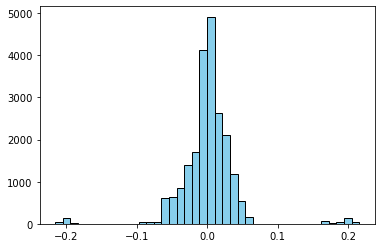

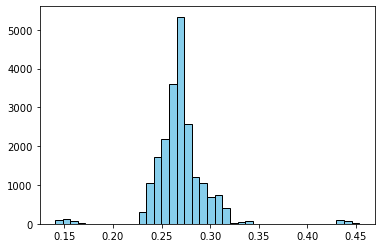

[-13.78932381] 1222.7421355220217
Mean square error: 112.9936665084664


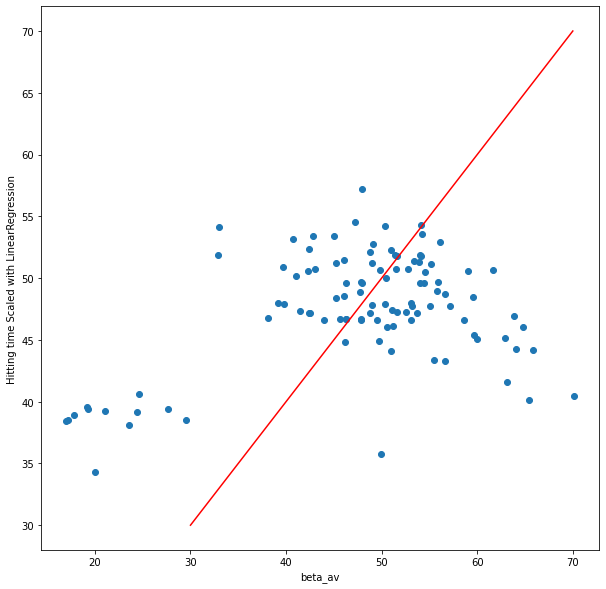

In [23]:
# generating hitting time of each 
from scipy.sparse import csgraph 
import seaborn as sns
from sklearn.linear_model import SGDRegressor,LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_squared_error
#plt.figure(figsize = (30,24))

import numpy as np


# Example Usage:
# 0 -> 1 -> 2


alpha = 0.1


def hitting_exp():
    scale = 5
    offset = 0
    weights = []
    weightss = []
    
    def weight(v,n1,n2): # edge weight for hitting time: higher weights for lower energy gain 
        scaled_diff = (v.iloc[coldict[n2]]-v.iloc[coldict[n1]])/(maxdiff)
        x = 1/(1 + np.exp((scaled_diff-scale)))
        #x =  (1-scaled_diff)**scale
        return x
        
    for scale in [-1]:
        hittingtime = [0]*m

        for i in range(m):
            v = df1.iloc[i]
            A = np.zeros((n,n))
            for n1 in graphdict:
                for n2 in graphdict[n1]:
                    A[coldict[n1],coldict[n2]] = weight(v,n1,n2) 
                    weights += [(v.iloc[coldict[n2]]-v.iloc[coldict[n1]])]
                    weightss += [A[coldict[n1],coldict[n2]]]
                    
            A[49,49] = 1                                    # index of the product (602 group): 49           
            hittingtime[i] = compute_hitting_time(A, 0, 49) # index of staring compount (0 group): 0
                                                                
        
        df2['hitting'] = hittingtime
        
        corr = df2['beta_av'].corr(df2['hitting'])
        print(f'Experiement with {scale}: {corr}')
    plt.hist(weights, bins=40, color='skyblue', edgecolor='black') # You can specify the number of bins
    plt.show()
    plt.hist(weightss, bins=40, color='skyblue', edgecolor='black') # You can specify the number of bins
    plt.show()
hitting_exp()

#plt.figure(figsize=(10,10))
#plt.scatter(df2['beta_av'],df2['hitting'])
#plt.show()


X = df2[['hitting']]#,'maxflow','mincut']]
y = df2['beta_av']

# 2. Split data into training and testing sets

# 3. Initialize the SGDClassifier with hinge loss
# max_iter sets the number of training epochs, random_state ensures reproducibility
regress = LinearRegression()


# 4. Train the model
regress.fit(X, y)

print(regress.coef_,regress.intercept_)
# 5. Make predictions ON THE TRAINING SET
y_pred = regress.predict(X)

# 6. Evaluate the model
#print(f"Predictions: {y_pred}")
#print(f"True labels: {y_test}")
print(f"Mean square error: {mean_squared_error(y, y_pred)}")

plt.figure(figsize=(10,10))
plt.scatter(df2['beta_av'],y_pred)
plt.xlabel('beta_av')
plt.ylabel('Hitting time Scaled with LinearRegression')
plt.plot([30,70],[30,70],color='red')
plt.show()





In [131]:
from sklearn.linear_model import Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import cross_val_score

# taking all the edges (weight/capacity) as features


def edgeFeatures():
    scale = 0
    def weight(v,n1,n2): # edge weight for hitting time: higher weights for lower energy gain 
        scaled_diff = (v.iloc[coldict[n2]]-v.iloc[coldict[n1]])/(maxdiff)
        x = 1/(1 + np.exp(5*(scaled_diff-scale)))
        #x =  (1-scaled_diff)**scale
        return x
    
    
    
    E = graph.number_of_edges()
    edgeW = [[0]*E for i in range(m)]
    edge_label = ['']*E
    
    count = 0
    for n1 in graphdict:
        for n2 in graphdict[n1]:
            for i in range(m):
                v = df1.iloc[i]
                edgeW[i][count] = weight(v,n1,n2)
            edge_label[count] = f'{n1} - {n2}'    
            count += 1
    
    
    
    new_data_2d = np.array(edgeW)
    return pd.DataFrame(new_data_2d,columns=edge_label,index=df1.index)
    
    #print(df_edges.head())
    
    
def CrossValid():
    
    df_edges = edgeFeatures()
    #df_edges['hitting'] = df2['hitting']
    #df_edges['maxflow'] = df2['maxflow']
    #btneck = ['357 - 494','507 - 494','494 - 642','494 - 538',
    #          '494 - 597','494 - 469','494 - 602','494 - 507','538 - 494','597 - 494']

    X  = df_edges #[btneck]
    y = df2['beta_av']
    model = Lasso(alpha=0.001, max_iter=10000)
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=10)
    
    rmse_mean = np.sqrt(-scores).mean()
    
    print("Scores:", scores)
    print('RMSE:',rmse_mean)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    
    #model = LassoCV(cv=5, random_state=0,max_iter=10000).fit(X, y)
    # print("Optimal alpha found:", model.alpha_) # 0.00708 


    
def Experiment():
    df_edges = edgeFeatures()
    
    #btneck = ['357 - 494','507 - 494','494 - 642','494 - 538',
    #          '494 - 597','494 - 469','494 - 602','494 - 507','538 - 494','597 - 494']
    
    X  = df_edges
    y = df2['beta_av']
    # 3. Initialize the SGDClassifier with hinge loss
    # max_iter sets the number of training epochs, random_state ensures reproducibility
    lasso_model = Lasso(alpha=0.002,max_iter=5000)
    #regress = LinearRegression()


    # 4. Train the model
    #regress.fit(X, y)
    lasso_model.fit(X,y)

    #print(regress.coef_[abs(regress.coef_)>0.001],regress.intercept_)
    #print(lasso_model.coef_,lasso_model.intercept_)
    
    # 5. Make predictions ON THE TRAINING SET
    #y_pred = regress.predict(X)
    y_pred = lasso_model.predict(X)

    # 6. Evaluate the model
    #print(f"Predictions: {y_pred}")
    #print(f"True labels: {y_test}")
    print(f"Root mean square error: {np.sqrt(mean_squared_error(y, y_pred))}")

    plt.figure(figsize=(10,10))
    plt.scatter(df2['beta_av'],y_pred)
    plt.xlabel('beta_av')
    plt.ylabel('Edge weights as features')
    plt.plot([20,70],[20,70],color='red')
    plt.show()
    
    # dispplay nonzero edges on the graph from lasso_model.coef_
    E = len(lasso_model.coef_)
    
    edgeweightdict = dict(zip(df_edges.columns,lasso_model.coef_))
    #print(edgeweightdict)
    
    def graph_weight_viz():
        CG = nx.DiGraph() 
        threshold = 0.0001
        def weight2color(w):
            if w< -threshold:
                return 'blue'
            elif w > threshold:
                return 'red'
            else:
                return 'gray'
            
        for source, targets in graphdict.items():
            for target in targets:
                if source != target:
                    weight = edgeweightdict[f'{source} - {target}']
                    #if abs(weight)<threshold: 
                    CG.add_edge(str(source), str(target),color=weight2color(weight), value=abs(weight))
        print('showing the network')  
        net = Network(notebook=True, height="1200px", width="100%", directed=True)
        net.from_nx(CG)

        # 4. Show the network
        net.show("colornetwork.html")
    graph_weight_viz()
    

CrossValid()    
#Experiment()


Scores: [ -13.28117205  -14.70918197  -10.60713128  -15.27246429  -31.19929977
  -19.1245747   -10.92699282  -37.03065831 -101.93967779 -100.06736622]
RMSE: 5.409401533492729
Mean: -35.415851922745695
Standard deviation: 33.80927901134835


In [17]:
import matplotlib.pyplot as plt
mi = 40

G = nx.Graph()
v = df1.iloc[mi]
A = np.zeros((n,n))

weights = []
for n1 in graphdict:
    for n2 in graphdict[n1]:
        A[coldict[n1],coldict[n2]] = energydiff(v,n1,n2) 
        weights += [A[coldict[n1],coldict[n2]]]
        G.add_edge(str(n1), str(n2),weight=A[coldict[n1],coldict[n2]])

plt.hist(weights, bins=40, color='skyblue', edgecolor='black') # You can specify the number of bins

volumn = sum(weights)

#for source, targets in graphdict.items():
#    for target in targets:
#        if source != target:
#            G.add_edge(str(source), str(target),weight=A)

net = Network(notebook=True, directed=True)
net.from_nx(G)

# 4. Show the network
net.show("networkmin.html",cdn_resources='in_line')


NameError: name 'energydiff' is not defined

[[0.         0.56565906 0.84522122 ... 0.         0.         0.        ]
 [0.         0.         0.80743671 ... 0.         0.         0.        ]
 [0.         0.19256329 0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
networkmax.html


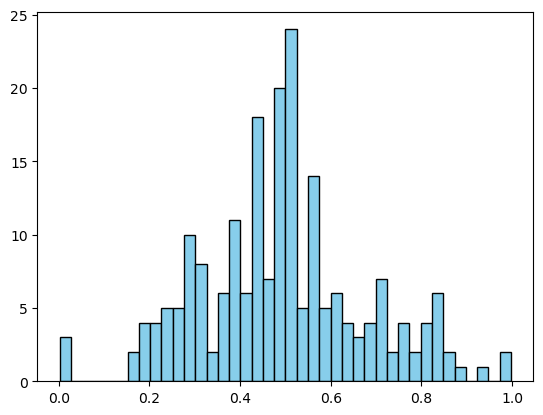

In [470]:
ma = 91

G = nx.Graph()
v = df1.iloc[ma]
A = np.zeros((n,n))

weights = []
for n1 in graphdict:
    for n2 in graphdict[n1]:
        A[coldict[n1],coldict[n2]] = energydiff(v,n1,n2) 
        weights += [A[coldict[n1],coldict[n2]]]
        G.add_edge(str(n1), str(n2),weight=A[coldict[n1],coldict[n2]])

print(A)
plt.hist(weights, bins=40, color='skyblue', edgecolor='black') # You can specify the number of bins


#for source, targets in graphdict.items():
#    for target in targets:
#        if source != target:
#            G.add_edge(str(source), str(target),weight=A)

net = Network(notebook=True, directed=True)
net.from_nx(G)

# 4. Show the network
net.show("networkmax.html")
